# Manual Day — Numerical Differentiation & Integration

Closed-agent, ~60 min. Complete every `# FILL IN` cell, then run the check.

## Mini-lecture: calculus on a machine

Numerical differentiation and numerical integration are the same trick run in
opposite directions. In both you replace a limit with a finite step, and nearly
everything that goes wrong follows from the fact that the step cannot be zero.

### Derivatives: the step you cannot shrink

You cannot evaluate $f'(x) = \lim_{h\to 0}\big(f(x+h)-f(x)\big)/h$ on a machine,
because a machine cannot take a limit. You pick a small $h$ and stop there. Taylor
tells you what that costs:

$$f(x+h) = f(x) + h f'(x) + \tfrac{h^2}{2}f''(x) + \dots$$

The **forward difference** $\big(f(x+h)-f(x)\big)/h$ is therefore off by
$\tfrac{h}{2}f''$, an error of order $h$. Evaluate on both sides instead and the
$f''$ terms cancel by symmetry, which leaves the **central difference**

$$f'(x) \approx \frac{f(x+h)-f(x-h)}{2h}, \qquad \text{error } \tfrac{h^2}{6}f''' = O(h^2).$$

Two function evaluations either way. At $h=10^{-5}$ on $f=\sin$ the error drops from
$3.5\times10^{-6}$ to $1.4\times10^{-11}$, so that accuracy is free and it came from
symmetry alone. Worth remembering when you build your own schemes.

There is a limit to how far that goes. Shrinking $h$ does not improve a difference
indefinitely, and the last problem in this notebook is where you go find the wall and
measure where it sits.

### Integration: walking forward with the slope you have

Now run the trick backwards. If you know the derivative everywhere,
$\mathrm{d}y/\mathrm{d}t = f(t,y)$, and you know where you start, you can walk:

$$y(t+\Delta t) \approx y(t) + \Delta t\, f\big(t, y(t)\big).$$

That is the **Euler step**, and it amounts to pretending the slope holds constant
across the interval. Each step costs $O(\Delta t^2)$ by Taylor, and over
$N = T/\Delta t$ steps those errors accumulate to $O(\Delta t)$ at fixed final time.
Euler is therefore **first order**: halve $\Delta t$ and you halve the error. (Two
different operations share the word "integration." This one is solving an ODE.
Summing the area under a fixed curve, the trapezoid rule and its relatives, comes up
in the Monte Carlo session.)

The error has a direction as well as a size. Euler follows the tangent line, and a
tangent lies above a concave curve and below a convex one. Newton's cooling below
rises toward equilibrium with $T'' < 0$, so every Euler step lands slightly high and
the numerical curve sits above the exact one. The check cell asserts that, because a
solver whose error has the wrong sign is broken in a way that agreement to two
decimals will happily hide.

### How to know it worked

Three habits, all of them used below. Compare against an exact answer when you have
one: here $T(10) = 56.145$ analytically, and Euler should land near $56.21$, close and
high. Check a limit you already know: the central difference at $x=\pi/4$ has to
reproduce $\cos(\pi/4) = 0.70710678$. And halve the step, since a first-order method
has to halve its error. When it doesn't, suspect your loop before you suspect the
method.

The loop itself should look familiar by now. Hold a state, apply a local update,
advance. It is the same skeleton as the power iteration and the training loop, and
Euler returns in week 4 for orbits and falling bodies, where conserved energy takes
over as the diagnostic.

## A note on classes

Most of your code this semester will be loops over arrays, but simulations get
unwieldy fast when the parameters live in one place, the state lives in another, and
the update rule lives in a third. A **class** bundles all three together.

```python
class Ball:
    def __init__(self, v0):     # runs once, when you create the object
        self.v = v0             # `self` is this particular ball
        self.y = 0.0

    def step(self, dt):         # a method: an operation on this ball's state
        self.v += -9.8 * dt
        self.y += self.v * dt

b = Ball(v0=5.0)                # make one
b.step(0.01)                    # advance it
print(b.y)                      # read its state
```

Three things to notice. `__init__` sets up the object and stores its parameters, so
you never have to pass them again. `self` refers to the specific object you are
working with, which is what lets `Ball(5.0)` and `Ball(-2.0)` coexist without their
variables colliding. And the update rule now travels with the data it updates.

That last point is the practical payoff. Running the same simulation at two different
step sizes becomes two lines instead of a copy-pasted loop, which matters a great deal
once you start checking convergence.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

T0   = 10.    # initial temperature
Ts   = 83.    # environment temperature
r    = 0.1    # cooling rate
dt   = 0.05   # time step
tmax = 60.    # maximum time
nsteps = int(tmax/dt)
t = np.linspace(dt, tmax, nsteps)   # time array

In [2]:
# GIVEN: exact solution of dT/dt = -r*(T - Ts), used only by the check
Tan = Ts + (T0 - Ts)*np.exp(-r*t)

## Euler solver: Newton's law of cooling

Newton's cooling obeys $\dfrac{dT}{dt} = -r\,(T - T_s)$. Integrate it with the Euler step $T \leftarrow T + \Delta t\,(-r(T-T_s))$, starting from $T=T_0$, and store the trajectory in `T_num` (length `nsteps`).

**Known answer:** the exact temperature at $t=10$ is $T=56.145$. Euler with this $\Delta t$ slightly overshoots ($\approx 56.21$).

In [3]:
# FILL IN: Euler-integrate dT/dt = -r*(T - Ts); store the trajectory in T_num (length nsteps)
T = T0
T_num = np.zeros(nsteps)
# your loop over nsteps here: update T with the Euler step and fill T_num[i]
for i in range(nsteps):
    T = T + dt * (-r) * (T - Ts)
    T_num[i] = T

numeric  T(t=10) = 56.212
analytic T(t=10) = 56.145
OK


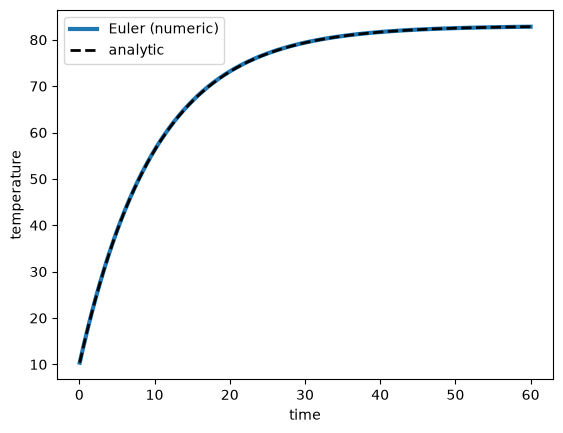

In [4]:
# CHECK — do not edit
i10 = int(np.argmin(np.abs(t - 10.0)))
print('numeric  T(t=10) = %.3f' % T_num[i10])
print('analytic T(t=10) = %.3f' % Tan[i10])
assert abs(T_num[i10] - 56.145) < 0.2, 'Euler result off — check your loop'
assert T_num[i10] > Tan[i10], 'forward Euler should slightly overshoot here'
print('OK')

plt.plot(t, T_num, lw=3, label='Euler (numeric)')
plt.plot(t, Tan, 'k--', lw=2, label='analytic')
plt.xlabel('time'); plt.ylabel('temperature'); plt.legend();

## The same solver, as a class

You now have a working cooling integrator written as a bare loop. Rewrite it as a
class called `CoolingSimulation` so that the parameters, the state, and the update
rule live in one object.

Give it three methods:

- `__init__(self, T0, Ts, r, dt)` stores the parameters, sets the current temperature
  to `T0`, and starts a history list containing it.
- `step(self)` advances the temperature by one Euler step and appends it to the
  history.
- `run(self, nsteps)` calls `step` that many times and returns the history as a numpy
  array.

**Known answer.** Your class has to reproduce the loop you already wrote, to the last
bit. If `run` disagrees with `T_num`, one of the two is wrong and you have no way to
tell which from the physics alone.

Once it works, notice what it buys you. The check cell runs the same simulation at
`dt` and at `dt/2` and compares the error against the exact curve, which is the
halving test from the mini-lecture. Written as a class it costs two lines.

In [14]:
# FILL IN: write CoolingSimulation with __init__, step, and run.
class CoolingSimulation:
    def __init__(self, T0, Ts, r, dt):
        self.T0 = T0
        self.Ts = Ts
        self.r = r
        self.dt = dt
        self.history = np.array([T0])

    def step(self):
        T = self.history[-1]
        T_new = T + self.dt * (-self.r) * (T - self.Ts)
        self.history = np.append(self.history, T_new)

    def run(self, nsteps):
        for i in range(nsteps):
            self.step()
        return self.history

In [15]:
# CHECK — do not edit
sim = CoolingSimulation(T0, Ts, r, dt)
traj = sim.run(nsteps)                      # history includes T0, so it is nsteps+1 long
assert np.allclose(traj[1:], T_num), "the class does not reproduce your loop"
print("class matches the loop: max |difference| = %.2e" % np.max(np.abs(traj[1:] - T_num)))

# now the payoff: the same run at two step sizes, and the halving test
def final_error(step):
    s = CoolingSimulation(T0, Ts, r, step)
    tr = s.run(int(tmax/step))
    return abs(tr[-1] - (Ts + (T0 - Ts)*np.exp(-r*tmax)))

e1, e2 = final_error(dt), final_error(dt/2)
print("error at dt   = %.3e" % e1)
print("error at dt/2 = %.3e   ratio = %.2f  (expect about 2 for a first-order method)"
      % (e2, e1/e2))
assert 1.7 < e1/e2 < 2.3, "halving dt did not halve the error, so this is not first order"
print("OK")

class matches the loop: max |difference| = 0.00e+00
error at dt   = 2.703e-03
error at dt/2 = 1.354e-03   ratio = 2.00  (expect about 2 for a first-order method)
OK


## Monte Carlo integration: estimating $\pi$

Everything so far has been deterministic: pick a step, pay a truncation error, shrink
the step. Here is the other way to integrate. Throw random points at a square that
contains the unit disc. The fraction landing inside is the ratio of the areas, so

$$\frac{N_{\rm in}}{N} \;\longrightarrow\; \frac{\pi r^2}{(2r)^2} = \frac{\pi}{4},
\qquad \pi \approx 4\,\frac{N_{\rm in}}{N}.$$

No grid, no step size, and nothing about the geometry beyond being able to ask
whether a point is inside. That last property is why Monte Carlo runs most of
computational physics: the test is cheap even when the region is complicated.

What you pay is accuracy. Estimate $\pi$ several times at each $N$ and the spread of
those estimates is your error bar, which falls like $1/\sqrt{N}$ from the central
limit theorem, no matter what you are integrating. That is a punishing rate. A
hundred times the work buys you one more decimal digit.

**Known answers.** Your estimate converges to $\pi$, and the error bar shrinks with
a slope of $-1/2$ on a log-log plot. Fit that slope the same way you fit the order of
a finite difference: it is the same measurement, applied to a statistical error
instead of a truncation error.

In [16]:
# GIVEN — the sweep, the repeats, and the answer we are aiming at.
rng   = np.random.default_rng(0)
Ns    = np.array([10, 100, 1000, 10_000, 100_000, 1_000_000])
reps  = 20            # independent estimates at each N, so we get an error bar
exact = np.pi

In [35]:
# FILL IN: estimate pi by throwing points at the square and counting the ones that
#          land in the disc, then repeat to get a mean and a spread at each N.
def mc_pi(N, rng):
    in_circle = 0
    for n in range(N):
        # circle radius is 1 so 2x2 square, choose x and y values between -1 and 1 so (0,0)=center
        x = 2*rng.random() - 1 # random is between 0 and 1
        y = 2*rng.random() - 1
        r = np.sqrt(x**2 + y**2)
        if r <= 1:
            in_circle = in_circle + 1
    pi = 4 * in_circle / N
    return pi


est  = [[mc_pi(N, rng) for rep in range(reps)] for N in Ns]      # shape (len(Ns), reps)
mean = np.mean(est, axis=1)      # the estimate at each N
err  = np.std(est, axis=1) / np.sqrt(reps)      # the spread of the estimates at each N

N =       10   pi = 3.14000 +/- 0.11756   |error| = 0.00159
N =      100   pi = 3.14200 +/- 0.04152   |error| = 0.00041
N =     1000   pi = 3.14260 +/- 0.01102   |error| = 0.00101
N =    10000   pi = 3.14094 +/- 0.00367   |error| = 0.00065
N =   100000   pi = 3.14380 +/- 0.00134   |error| = 0.00221
N =  1000000   pi = 3.14153 +/- 0.00032   |error| = 0.00006

fitted slope of the error bar: -0.508   (expect -0.5)
OK


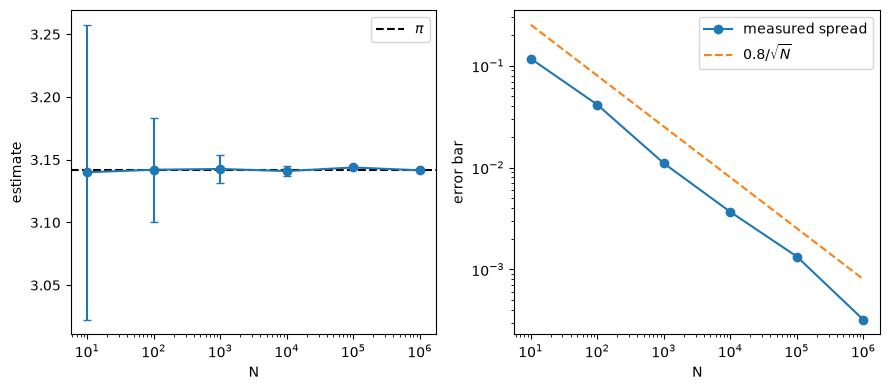

In [36]:
# CHECK — do not edit
for N, m, e in zip(Ns, mean, err):
    print("N = %8d   pi = %.5f +/- %.5f   |error| = %.5f" % (N, m, e, abs(m - exact)))

assert abs(mean[-1] - exact) < 0.01, "not converging to pi at the largest N"

slope = np.polyfit(np.log10(Ns), np.log10(err), 1)[0]
print("\nfitted slope of the error bar: %.3f   (expect -0.5)" % slope)
assert abs(slope + 0.5) < 0.12, "the error is not falling like 1/sqrt(N)"
print("OK")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4))
a1.errorbar(Ns, mean, yerr=err, fmt="o-", capsize=3)
a1.axhline(exact, ls="--", c="k", label=r"$\pi$")
a1.set_xscale("log"); a1.set_xlabel("N"); a1.set_ylabel("estimate"); a1.legend()
a2.loglog(Ns, err, "o-", label="measured spread")
a2.loglog(Ns, 0.8/np.sqrt(Ns), "--", label=r"$0.8/\sqrt{N}$")
a2.set_xlabel("N"); a2.set_ylabel("error bar"); a2.legend()
plt.tight_layout();

## 3. Challenge — how small should $h$ be?

Smaller $h$ means smaller truncation error, so the obvious strategy is to make $h$ as
small as the machine allows. Test that strategy.

Sweep $h$ from $10^{-1}$ down to $10^{-15}$ and record the error of both the forward
and the central difference for $f=\sin$ at $x_0=\pi/4$, where the exact answer is
$\cos(\pi/4)$. Plot the error against $h$ on log-log axes.

Two pieces of method you will need. On a straight stretch of a log-log plot, the
slope is the order of the method, so fit it rather than eyeballing it: that
measurement is the cleanest experimental statement of how accurate an algorithm is,
and you will use it repeatedly this semester. And fit the slope only over the range
where the plot is actually straight, which means looking at the plot before you fit.

**Known answer.** The fitted slopes over the large-$h$ end should reproduce the
orders derived in the mini-lecture, 1 for forward and 2 for central. What the small-$h$
end does is the part worth finding out for yourself, so run it before you read the
next cell.

In [45]:
# GIVEN — the test function, the point, the exact answer, and the sweep.
f     = np.sin
x0    = np.pi / 4
exact = np.cos(x0)                      # what we are trying to recover
hs    = 10.0 ** np.arange(-1, -16, -0.1)  # 1e-1 down to 1e-15
eps   = np.finfo(float).eps             # machine precision, ~2.2e-16

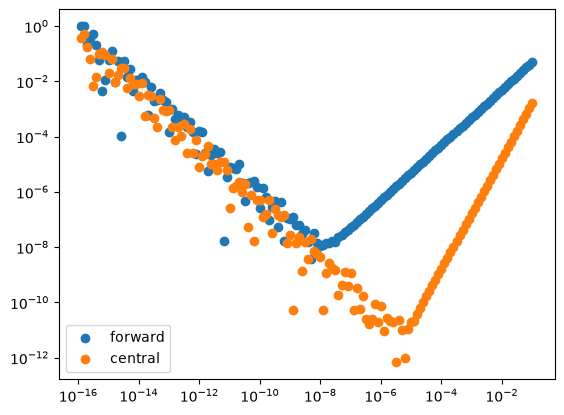

In [48]:
# FILL IN: the error of the forward and of the central difference against `exact`,
#          one entry per h in hs.

def central_diff(f, x0, h):
    return (f(x0 + h) - f(x0 - h)) / (2*h)

def forward_diff(f, x0, h):
    return (f(x0 + h) - f(x0)) / h

err_fwd = abs([forward_diff(f, x0, h) for h in hs] - exact) / exact
err_cen = abs([central_diff(f, x0, h) for h in hs] - exact) / exact

plt.scatter(hs, err_fwd, label='forward')
plt.scatter(hs, err_cen, label='central')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

    h        forward      central
  1e-01     5.16e-02     1.67e-03
  8e-02     4.07e-02     1.05e-03
  6e-02     3.22e-02     6.63e-04
  5e-02     2.55e-02     4.19e-04
  4e-02     2.02e-02     2.64e-04
  3e-02     1.60e-02     1.67e-04
  3e-02     1.27e-02     1.05e-04
  2e-02     1.00e-02     6.63e-05
  2e-02     7.97e-03     4.19e-05
  1e-02     6.32e-03     2.64e-05
  1e-02     5.02e-03     1.67e-05
  8e-03     3.98e-03     1.05e-05
  6e-03     3.16e-03     6.64e-06
  5e-03     2.51e-03     4.19e-06
  4e-03     1.99e-03     2.64e-06
  3e-03     1.58e-03     1.67e-06
  3e-03     1.26e-03     1.05e-06
  2e-03     9.98e-04     6.64e-07
  2e-03     7.93e-04     4.19e-07
  1e-03     6.30e-04     2.64e-07
  1e-03     5.00e-04     1.67e-07
  8e-04     3.97e-04     1.05e-07
  6e-04     3.16e-04     6.64e-08
  5e-04     2.51e-04     4.19e-08
  4e-04     1.99e-04     2.64e-08
  3e-04     1.58e-04     1.67e-08
  3e-04     1.26e-04     1.05e-08
  2e-04     9.98e-05     6.64e-09
  2e-04     7.

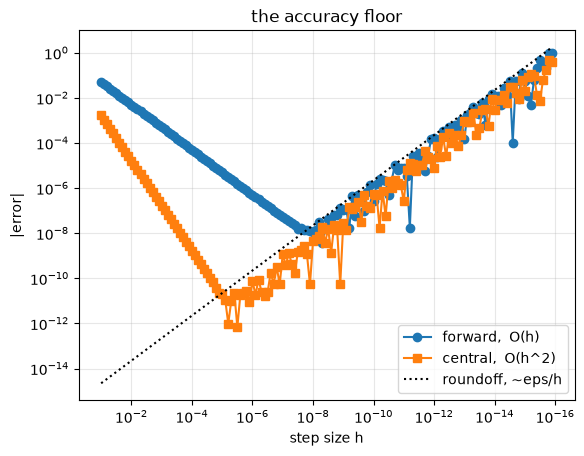

In [49]:
# CHECK — do not edit
print("    h        forward      central")
for h, a, b in zip(hs, err_fwd, err_cen):
    print("  %.0e     %.2e     %.2e" % (h, a, b))

i_f, i_c = np.argmin(err_fwd), np.argmin(err_cen)
print()
print("forward: best at h = %.0e, error %.1e   (predicted h ~ eps**(1/2) = %.0e)"
      % (hs[i_f], err_fwd[i_f], eps ** 0.5))
print("central: best at h = %.0e, error %.1e   (predicted h ~ eps**(1/3) = %.0e)"
      % (hs[i_c], err_cen[i_c], eps ** (1 / 3)))

# 1) the error is NOT monotonic in h -- the whole point
assert err_fwd[-1] > 100 * err_fwd[i_f], "forward error should blow up at tiny h"
assert err_cen[-1] > 100 * err_cen[i_c], "central error should blow up at tiny h"
print("blow-up past the optimum: forward %.0e x worse, central %.0e x worse"
      % (err_fwd[-1] / err_fwd[i_f], err_cen[-1] / err_cen[i_c]))

# 2) the optimum sits within a decade of the predicted balance point
assert abs(np.log10(hs[i_f]) - np.log10(eps ** 0.5)) <= 1.0, "forward optimum misplaced"
assert abs(np.log10(hs[i_c]) - np.log10(eps ** (1 / 3))) <= 1.0, "central optimum misplaced"

# 3) in the truncation regime the log-log slope IS the order of the method
win = (hs >= 1e-3) & (hs <= 1e-1)
s_f = np.polyfit(np.log10(hs[win]), np.log10(err_fwd[win]), 1)[0]
s_c = np.polyfit(np.log10(hs[win]), np.log10(err_cen[win]), 1)[0]
print("fitted order: forward %.3f (expect 1),  central %.3f (expect 2)" % (s_f, s_c))
assert abs(s_f - 1) < 0.1, "forward difference is not first order"
assert abs(s_c - 2) < 0.1, "central difference is not second order"
print("OK")

plt.loglog(hs, err_fwd, "o-", label="forward,  O(h)")
plt.loglog(hs, err_cen, "s-", label="central,  O(h^2)")
plt.loglog(hs, eps / hs, "k:", label="roundoff, ~eps/h")
plt.gca().invert_xaxis()
plt.xlabel("step size h"); plt.ylabel("|error|")
plt.title("the accuracy floor"); plt.legend(); plt.grid(True, which="both", alpha=.3);

### What you just measured

The error fell, bottomed out, and then climbed again. Here is the mechanism.

$f(x+h)$ and $f(x-h)$ agree in their leading digits, so subtracting them throws those
digits away and keeps the noise in the last ones. This is **catastrophic
cancellation**, and dividing by $2h$ then amplifies the noise. With machine precision
$\epsilon \approx 2\times10^{-16}$ the two effects add up to

$$\text{total error} \;\sim\; \underbrace{\tfrac{h^2}{6}|f'''|}_{\text{truncation}} \;+\; \underbrace{\epsilon|f|/h}_{\text{roundoff}},$$

which falls and then rises. Balancing the two terms puts the best $h$ at
$\epsilon^{1/3} \approx 6\times10^{-6}$ for the central difference and
$\epsilon^{1/2} \approx 10^{-8}$ for the forward one, which is what your sweep found.

So the central difference bottoms out near $3\times10^{-12}$, and that is a floor:
the best first derivative of $\sin$ at $\pi/4$ available in double precision by
differencing. Trying harder will not move it, since it is a property of subtracting
nearby floating-point numbers. Whatever intuition you carry from exact mathematics,
that a smaller step is always better, is false on a machine.

*A question for Friday.* The floor comes from cancellation in $f(x+h)-f(x-h)$. What
would you have to change to get below it, and does your agent know?